### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from sklearn.decomposition import PCA
from hebbian.utils import rotation_matrix_nd, rotate_cov_nd, eig_sorted, ellipse_xy_from_cov, instantiate_before_after_X, before_after_distribution

In [2]:
N = 10
m = 2
phi_deg = 45.0
n_samples = 10001
X_seed = 0
# get /sigma
Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)

# Do PCA on X before and X after
pca_before = PCA(n_components=m)
pca_before.fit(X_before)
X_before_pca = pca_before.transform(X_before)
pca_after = PCA(n_components=m)
pca_after.fit(X_after)
X_after_pca = pca_after.transform(X_after)

# eigen values of X before and X after
print(f"Eigen values of X before: {pca_before.explained_variance_}")
print(f"Eigen values of X after: {pca_after.explained_variance_}")

# variance explained by each PC
print(f"Variance explained by each PC of X before: {pca_before.explained_variance_ratio_}")
print(f"Variance explained by each PC of X after: {pca_after.explained_variance_ratio_}")



Eigen values of X before: [1.18832136 0.79510762]
Eigen values of X after: [1.22674947 0.80661225]
Variance explained by each PC of X before: [0.59912473 0.40087527]
Variance explained by each PC of X after: [0.60331099 0.39668901]


### Apply Leen's complete model to before and after drifted models

In [3]:
from hebbian.models import LeenCompletePCA
from hebbian.utils import Y_aligned_training_testing, Y_aligned_training_testing_online

In [4]:
# runs = 10
model_paras = dict(
    input_dim=N, output_dim=m,
    eta_w=5e-5,          # base
    eta_v=2e-3,          # ~4x eta_w
    C=2.0,
    ema_alpha=0.03,
    symmetrize_V=True,
    seed=None,
    noise_level=0.001,
    settling_steps=10
)

model_paras_after = dict(
    eta_w=5e-5,
    eta_v=2e-4,
#     eta_w=6e-5,          # base
#     eta_v=5e-4,          # ~4x eta_w
)

### Multiple runs

In [7]:
### Two phase training and testing

def bar_graph_with_error_bars(df_best_corr, title):
    figure = plt.figure()
    means = df_best_corr.mean(axis=0)
    stds = df_best_corr.std(axis=0)
    plt.figure(figsize=(10, 6))
    plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
    plt.ylabel('Mean Absolute Correlation')
    plt.title(title)
    plt.show()

def two_phase_training_testing(model, data_before, data_after, m, model_paras_after=None, runs =10, graph = True):
    df_best_corr_after = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    df_best_corr_before = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])

    for run in range(runs):
        print(f"run {run+1:2d}")
        print(f"X_before")
        order, similarity = Y_aligned_training_testing_online(model, data_before, graph=True, alignment="cov")
        # print(f"After first phase: model.W = {model.W}, model.V: {model.V}")
        print(f"W after first phase: {model.W}")
        # print(f"Y_output_after_first_phase: {model.transform(data_before)}")
       # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_before.iloc[run, :] = ordered_similarity 

#################################################################
        print(f"X_after")
        # update the model parameters, if provided
        if model_paras_after is not None:
            for key, value in model_paras_after.items():
                if hasattr(model, key):
                    setattr(model, key, value)

        order, similarity = Y_aligned_training_testing_online(model, data_after, graph=True, alignment="cosine")
        print(f"after second phase: model.W = {model.W}")
        try:
            print(f"model.V = {model.V}")
        except AttributeError:
            pass
        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_after.iloc[run, :] = ordered_similarity
        # print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")
        model.reset()

    if graph == True:
        bar_graph_with_error_bars(df_best_corr_before, "Mean Absolute Correlation (before)")
        bar_graph_with_error_bars(df_best_corr_after, "Mean Absolute Correlation (after)")

### Golden standard: Sanger's rule

run  1
X_before
model.W is not defined
step    0 | order = [1 0] | best|corr|= [0.041 0.032]
step 1000 | order = [1 0] | best|corr|= [5.03  2.093]
step 2000 | order = [1 0] | best|corr|= [5.03  2.132]
step 3000 | order = [1 0] | best|corr|= [4.949 2.14 ]
step 4000 | order = [1 0] | best|corr|= [5.016 2.045]
step 5000 | order = [1 0] | best|corr|= [5.043 2.06 ]
step 6000 | order = [1 0] | best|corr|= [4.916 1.974]
step 7000 | order = [1 0] | best|corr|= [4.992 2.005]
step 8000 | order = [1 0] | best|corr|= [5.039 2.116]
step 9000 | order = [1 0] | best|corr|= [4.963 1.994]
step 10000 | order = [1 0] | best|corr|= [5.014 2.106]


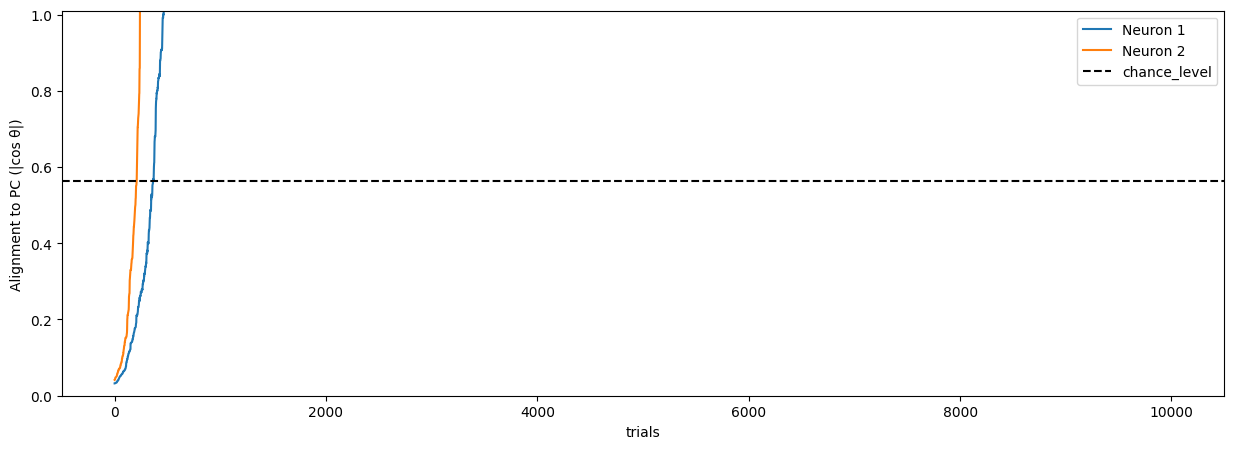

W after first phase: [[-0.25749462 -0.44322313 -0.11372259  0.07322452  0.18174023  0.24866867
   0.19426004  0.09037432  0.12096813 -0.75368135]
 [ 0.02679425 -0.15644493 -0.50079267  0.1023819  -0.35743061 -0.41692043
   0.29010718 -0.53083877  0.20082312  0.0736055 ]]
X_after
W: [[-0.25749462 -0.44322313 -0.11372259  0.07322452  0.18174023  0.24866867
   0.19426004  0.09037432  0.12096813 -0.75368135]
 [ 0.02679425 -0.15644493 -0.50079267  0.1023819  -0.35743061 -0.41692043
   0.29010718 -0.53083877  0.20082312  0.0736055 ]]
step    0 | order = [1 0] | best|corr|= [0.939 0.985]
step 1000 | order = [0 1] | best|corr|= [0.842 0.707]
step 2000 | order = [1 0] | best|corr|= [0.697 0.737]
step 3000 | order = [0 1] | best|corr|= [0.858 0.77 ]
step 4000 | order = [0 1] | best|corr|= [0.776 0.716]
step 5000 | order = [0 1] | best|corr|= [0.941 0.966]
step 6000 | order = [0 1] | best|corr|= [0.834 0.752]
step 7000 | order = [0 1] | best|corr|= [0.83  0.817]
step 8000 | order = [0 1] | best|c

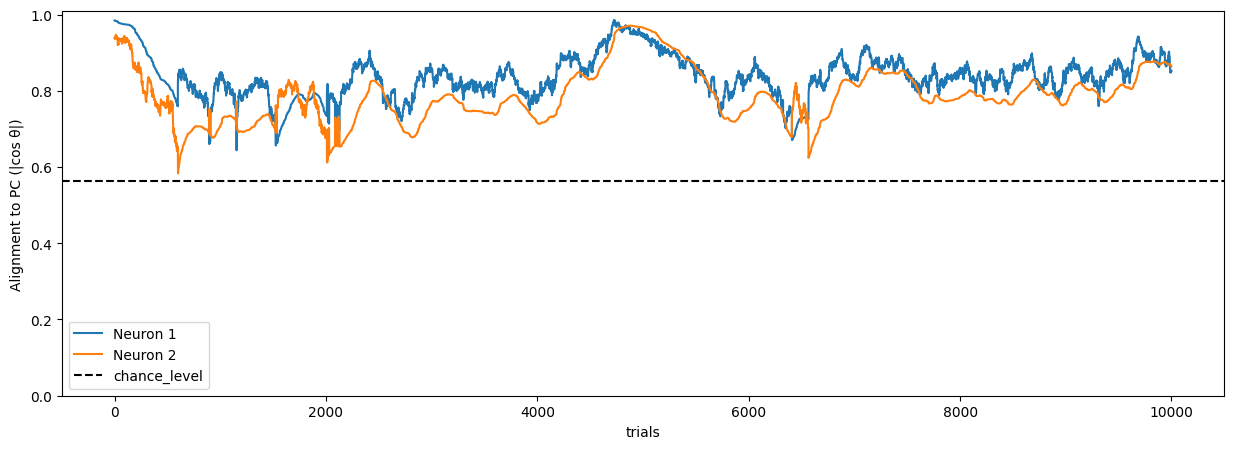

after second phase: model.W = [[-0.19683195 -0.21611537  0.22355591 -0.01065183  0.34395821  0.42693262
  -0.03946034  0.384905   -0.03678885 -0.57320318]
 [-0.16179746 -0.41867383 -0.42619011  0.12213072 -0.12005483 -0.11434721
   0.33680307 -0.30404049  0.22368873 -0.47691365]]
run  2
X_before
W: [[-0.01190554  0.02395401  0.00955627 -0.00542381 -0.01625114  0.01039664
   0.00592754  0.00788936 -0.00520802  0.00456461]
 [-0.00968216  0.01304969 -0.00266276  0.01157524  0.01480743  0.01212071
  -0.0167238  -0.021233    0.00418403 -0.01376909]]
step    0 | order = [0 1] | best|corr|= [0.03  0.045]
step 1000 | order = [1 0] | best|corr|= [4.798 1.954]
step 2000 | order = [1 0] | best|corr|= [4.794 2.035]
step 3000 | order = [1 0] | best|corr|= [4.724 2.041]
step 4000 | order = [1 0] | best|corr|= [4.784 1.955]
step 5000 | order = [1 0] | best|corr|= [4.807 1.962]
step 6000 | order = [1 0] | best|corr|= [4.702 1.894]
step 7000 | order = [1 0] | best|corr|= [4.763 1.917]
step 8000 | order

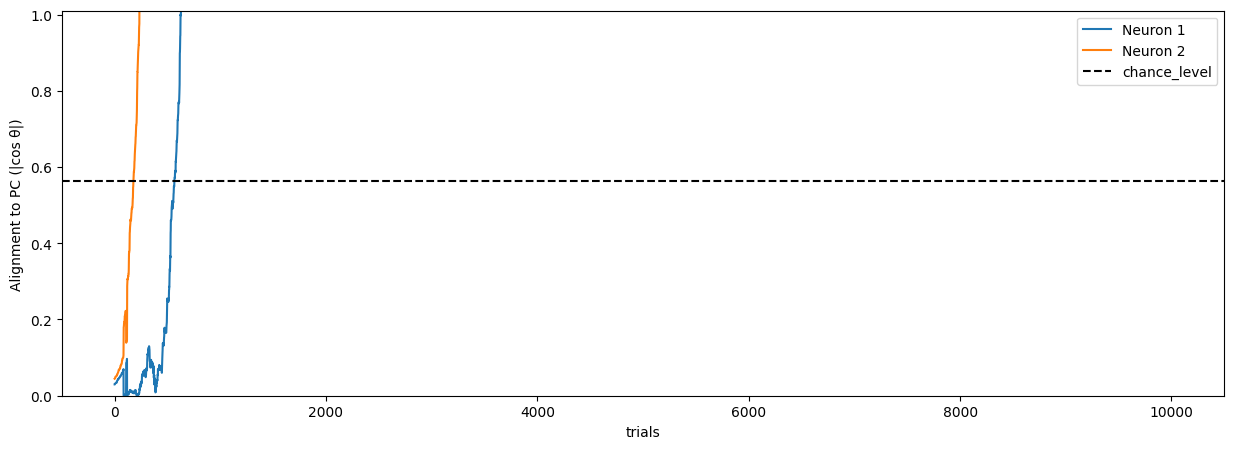

W after first phase: [[ 0.245425    0.42323395  0.11038151 -0.07021916 -0.17190769 -0.23549513
  -0.18635877 -0.08411452 -0.11612619  0.71837253]
 [-0.02481892  0.15051678  0.4780583  -0.09787799  0.34044739  0.39700494
  -0.27730692  0.50613307 -0.19192341 -0.06804572]]
X_after
W: [[ 0.245425    0.42323395  0.11038151 -0.07021916 -0.17190769 -0.23549513
  -0.18635877 -0.08411452 -0.11612619  0.71837253]
 [-0.02481892  0.15051678  0.4780583  -0.09787799  0.34044739  0.39700494
  -0.27730692  0.50613307 -0.19192341 -0.06804572]]
step    0 | order = [1 0] | best|corr|= [0.94  0.984]
step 1000 | order = [0 1] | best|corr|= [0.841 0.706]
step 2000 | order = [1 0] | best|corr|= [0.697 0.737]
step 3000 | order = [0 1] | best|corr|= [0.858 0.77 ]
step 4000 | order = [0 1] | best|corr|= [0.776 0.716]
step 5000 | order = [0 1] | best|corr|= [0.941 0.966]
step 6000 | order = [0 1] | best|corr|= [0.834 0.752]
step 7000 | order = [0 1] | best|corr|= [0.83  0.817]
step 8000 | order = [0 1] | best|c

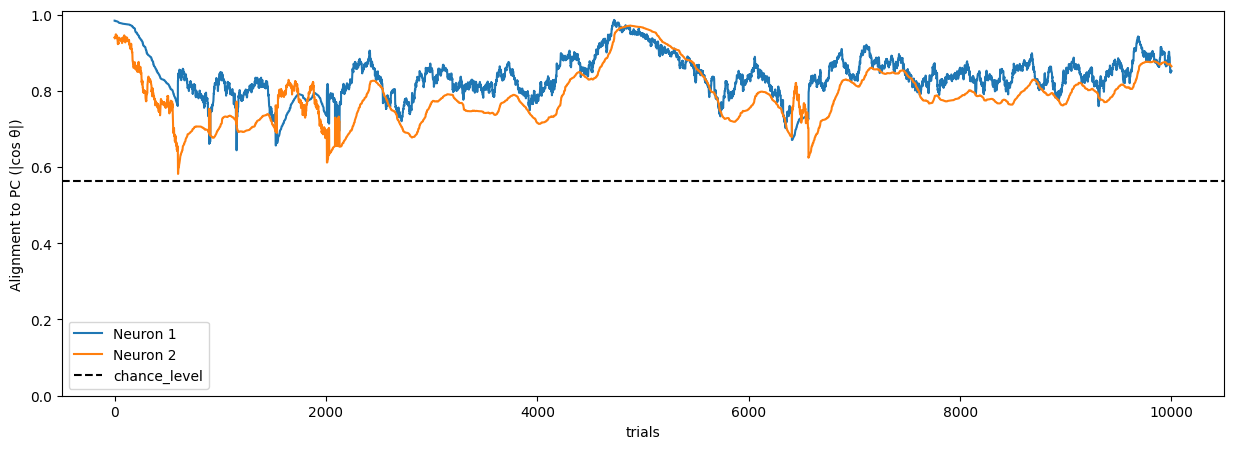

after second phase: model.W = [[ 0.19683195  0.21611537 -0.22355591  0.01065183 -0.34395821 -0.42693262
   0.03946034 -0.384905    0.03678885  0.57320318]
 [ 0.16179746  0.41867383  0.42619011 -0.12213072  0.12005483  0.11434721
  -0.33680307  0.30404049 -0.22368873  0.47691365]]
run  3
X_before
W: [[ 0.00271627  0.00442695 -0.00776348 -0.0009904   0.01107282 -0.0084551
   0.01374011  0.00433198  0.01015614  0.02143398]
 [-0.01734599 -0.00998693 -0.00795852 -0.00653118 -0.00848498 -0.01428193
  -0.00435615 -0.00298416  0.00879181  0.00620174]]
step    0 | order = [1 0] | best|corr|= [0.065 0.034]
step 1000 | order = [1 0] | best|corr|= [4.794 2.012]
step 2000 | order = [1 0] | best|corr|= [4.794 2.035]
step 3000 | order = [1 0] | best|corr|= [4.724 2.041]
step 4000 | order = [1 0] | best|corr|= [4.784 1.955]
step 5000 | order = [1 0] | best|corr|= [4.807 1.962]
step 6000 | order = [1 0] | best|corr|= [4.702 1.894]
step 7000 | order = [1 0] | best|corr|= [4.763 1.917]
step 8000 | order 

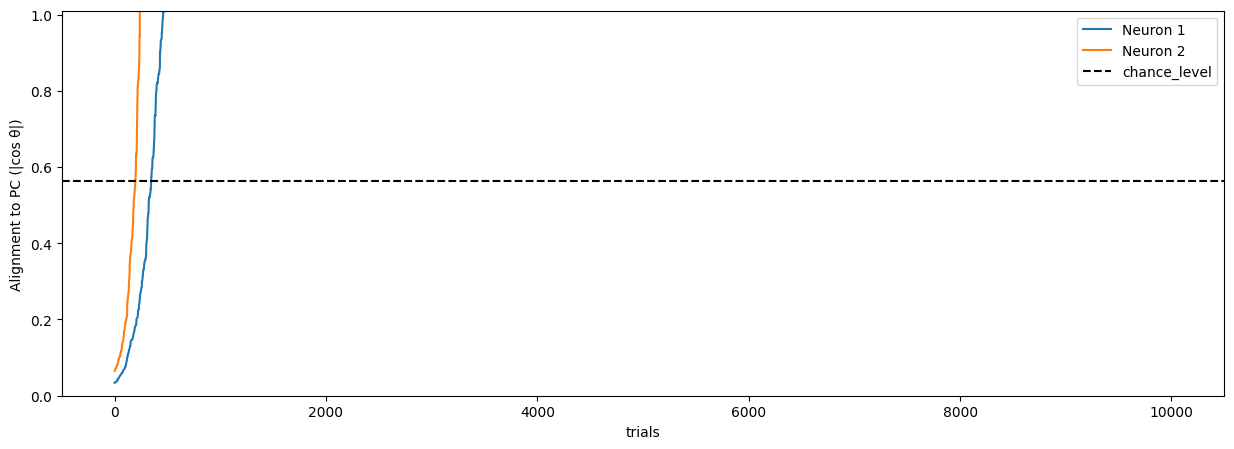

W after first phase: [[ 0.245425    0.42323395  0.11038151 -0.07021916 -0.17190769 -0.23549513
  -0.18635877 -0.08411452 -0.11612619  0.71837253]
 [ 0.02481892 -0.15051678 -0.4780583   0.09787799 -0.34044739 -0.39700494
   0.27730692 -0.50613307  0.19192341  0.06804572]]
X_after
W: [[ 0.245425    0.42323395  0.11038151 -0.07021916 -0.17190769 -0.23549513
  -0.18635877 -0.08411452 -0.11612619  0.71837253]
 [ 0.02481892 -0.15051678 -0.4780583   0.09787799 -0.34044739 -0.39700494
   0.27730692 -0.50613307  0.19192341  0.06804572]]
step    0 | order = [1 0] | best|corr|= [0.94  0.984]
step 1000 | order = [0 1] | best|corr|= [0.841 0.706]
step 2000 | order = [1 0] | best|corr|= [0.697 0.737]
step 3000 | order = [0 1] | best|corr|= [0.858 0.77 ]
step 4000 | order = [0 1] | best|corr|= [0.776 0.716]
step 5000 | order = [0 1] | best|corr|= [0.941 0.966]
step 6000 | order = [0 1] | best|corr|= [0.834 0.752]
step 7000 | order = [0 1] | best|corr|= [0.83  0.817]
step 8000 | order = [0 1] | best|c

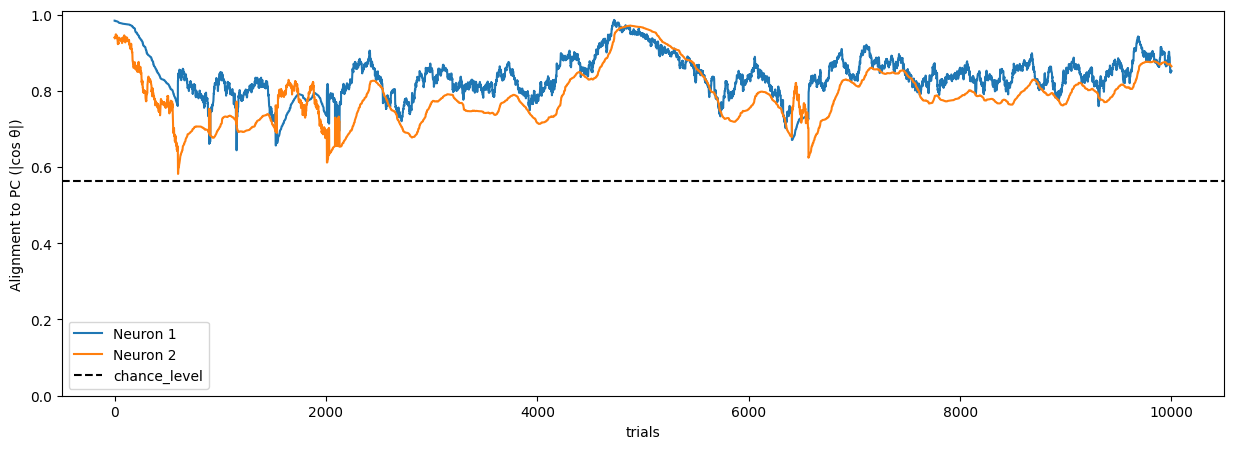

after second phase: model.W = [[ 0.19683195  0.21611537 -0.22355591  0.01065183 -0.34395821 -0.42693262
   0.03946034 -0.384905    0.03678885  0.57320318]
 [-0.16179746 -0.41867383 -0.42619011  0.12213072 -0.12005483 -0.11434721
   0.33680307 -0.30404049  0.22368873 -0.47691365]]
run  4
X_before
W: [[-0.01228493 -0.00538015  0.00862083 -0.00806724  0.00446382  0.01408494
  -0.00470612  0.00362545 -0.00174333  0.00435523]
 [ 0.00164157 -0.01878714  0.00717949 -0.00505978 -0.01104213  0.00186727
  -0.00294049 -0.01505415 -0.0075735  -0.01827918]]
step    0 | order = [0 1] | best|corr|= [0.031 0.084]
step 1000 | order = [1 0] | best|corr|= [4.742 1.923]
step 2000 | order = [1 0] | best|corr|= [4.793 2.035]
step 3000 | order = [1 0] | best|corr|= [4.724 2.041]
step 4000 | order = [1 0] | best|corr|= [4.784 1.955]
step 5000 | order = [1 0] | best|corr|= [4.807 1.962]
step 6000 | order = [1 0] | best|corr|= [4.702 1.894]
step 7000 | order = [1 0] | best|corr|= [4.763 1.917]
step 8000 | order

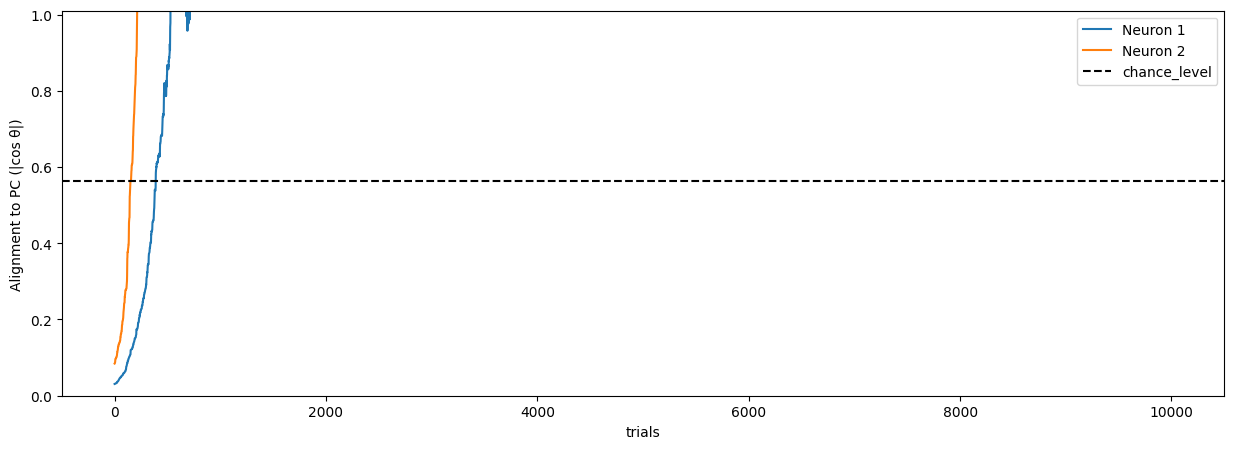

W after first phase: [[-0.245425   -0.42323395 -0.11038151  0.07021916  0.17190769  0.23549513
   0.18635877  0.08411452  0.11612619 -0.71837253]
 [ 0.02481892 -0.15051678 -0.4780583   0.09787799 -0.34044739 -0.39700494
   0.27730692 -0.50613307  0.19192341  0.06804572]]
X_after
W: [[-0.245425   -0.42323395 -0.11038151  0.07021916  0.17190769  0.23549513
   0.18635877  0.08411452  0.11612619 -0.71837253]
 [ 0.02481892 -0.15051678 -0.4780583   0.09787799 -0.34044739 -0.39700494
   0.27730692 -0.50613307  0.19192341  0.06804572]]
step    0 | order = [1 0] | best|corr|= [0.94  0.984]
step 1000 | order = [0 1] | best|corr|= [0.841 0.706]
step 2000 | order = [1 0] | best|corr|= [0.697 0.737]
step 3000 | order = [0 1] | best|corr|= [0.858 0.77 ]
step 4000 | order = [0 1] | best|corr|= [0.776 0.716]
step 5000 | order = [0 1] | best|corr|= [0.941 0.966]
step 6000 | order = [0 1] | best|corr|= [0.834 0.752]
step 7000 | order = [0 1] | best|corr|= [0.83  0.817]
step 8000 | order = [0 1] | best|c

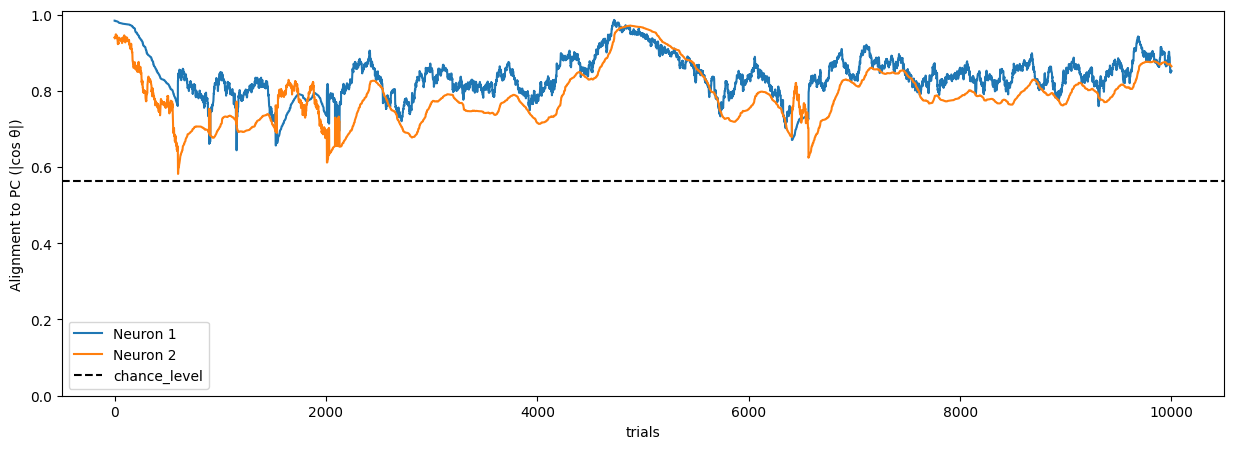

after second phase: model.W = [[-0.19683195 -0.21611537  0.22355591 -0.01065183  0.34395821  0.42693262
  -0.03946034  0.384905   -0.03678885 -0.57320318]
 [-0.16179746 -0.41867383 -0.42619011  0.12213072 -0.12005483 -0.11434721
   0.33680307 -0.30404049  0.22368873 -0.47691365]]
run  5
X_before
W: [[-0.00069269  0.00856354 -0.00710197 -0.0245228   0.00512982  0.01037788
  -0.02429998 -0.0013927   0.00480815  0.00348768]
 [ 0.01609923 -0.01992175 -0.00366247  0.01098267  0.00145962 -0.00580098
  -0.01758047 -0.0010263  -0.01630769  0.00388237]]
step    0 | order = [0 1] | best|corr|= [0.029 0.018]
step 1000 | order = [1 0] | best|corr|= [4.798 1.928]
step 2000 | order = [1 0] | best|corr|= [4.794 2.035]
step 3000 | order = [1 0] | best|corr|= [4.724 2.041]
step 4000 | order = [1 0] | best|corr|= [4.784 1.955]
step 5000 | order = [1 0] | best|corr|= [4.807 1.962]
step 6000 | order = [1 0] | best|corr|= [4.702 1.894]
step 7000 | order = [1 0] | best|corr|= [4.763 1.917]
step 8000 | order

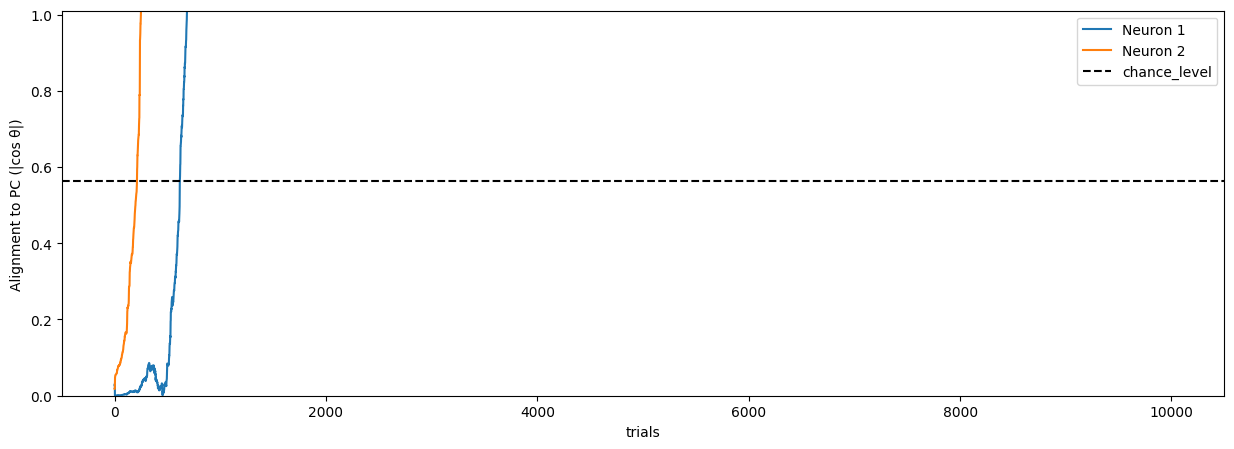

W after first phase: [[ 0.245425    0.42323395  0.11038151 -0.07021916 -0.17190769 -0.23549513
  -0.18635877 -0.08411452 -0.11612619  0.71837253]
 [ 0.02481892 -0.15051678 -0.4780583   0.09787799 -0.34044739 -0.39700494
   0.27730692 -0.50613307  0.19192341  0.06804572]]
X_after
W: [[ 0.245425    0.42323395  0.11038151 -0.07021916 -0.17190769 -0.23549513
  -0.18635877 -0.08411452 -0.11612619  0.71837253]
 [ 0.02481892 -0.15051678 -0.4780583   0.09787799 -0.34044739 -0.39700494
   0.27730692 -0.50613307  0.19192341  0.06804572]]
step    0 | order = [1 0] | best|corr|= [0.94  0.984]
step 1000 | order = [0 1] | best|corr|= [0.841 0.706]
step 2000 | order = [1 0] | best|corr|= [0.697 0.737]
step 3000 | order = [0 1] | best|corr|= [0.858 0.77 ]
step 4000 | order = [0 1] | best|corr|= [0.776 0.716]
step 5000 | order = [0 1] | best|corr|= [0.941 0.966]
step 6000 | order = [0 1] | best|corr|= [0.834 0.752]
step 7000 | order = [0 1] | best|corr|= [0.83  0.817]
step 8000 | order = [0 1] | best|c

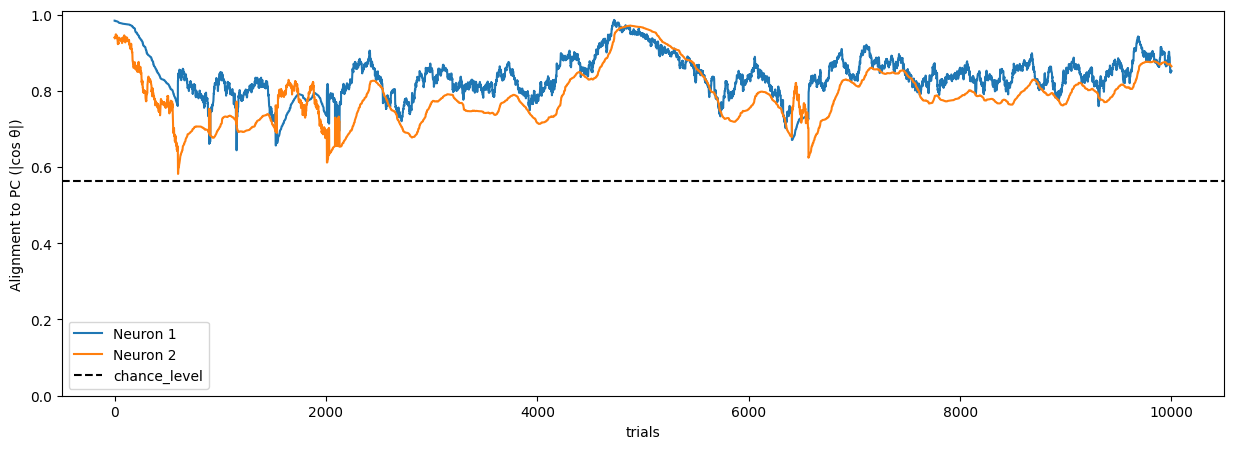

after second phase: model.W = [[ 0.19683195  0.21611537 -0.22355591  0.01065183 -0.34395821 -0.42693262
   0.03946034 -0.384905    0.03678885  0.57320318]
 [-0.16179746 -0.41867383 -0.42619011  0.12213072 -0.12005483 -0.11434721
   0.33680307 -0.30404049  0.22368873 -0.47691365]]
run  6
X_before
W: [[ 0.01062865 -0.00498371  0.01383684 -0.00816539  0.01491922 -0.00199664
   0.01012187 -0.013096    0.00155226  0.01204427]
 [-0.00395261  0.00574347  0.01574029 -0.00423959 -0.00395087 -0.01145831
  -0.01151009 -0.01554556 -0.01916175 -0.01204982]]
step    0 | order = [1 0] | best|corr|= [0.043 0.008]
step 1000 | order = [1 0] | best|corr|= [4.796 1.921]
step 2000 | order = [1 0] | best|corr|= [4.794 2.035]
step 3000 | order = [1 0] | best|corr|= [4.724 2.041]
step 4000 | order = [1 0] | best|corr|= [4.784 1.955]
step 5000 | order = [1 0] | best|corr|= [4.807 1.962]
step 6000 | order = [1 0] | best|corr|= [4.702 1.894]
step 7000 | order = [1 0] | best|corr|= [4.763 1.917]
step 8000 | order

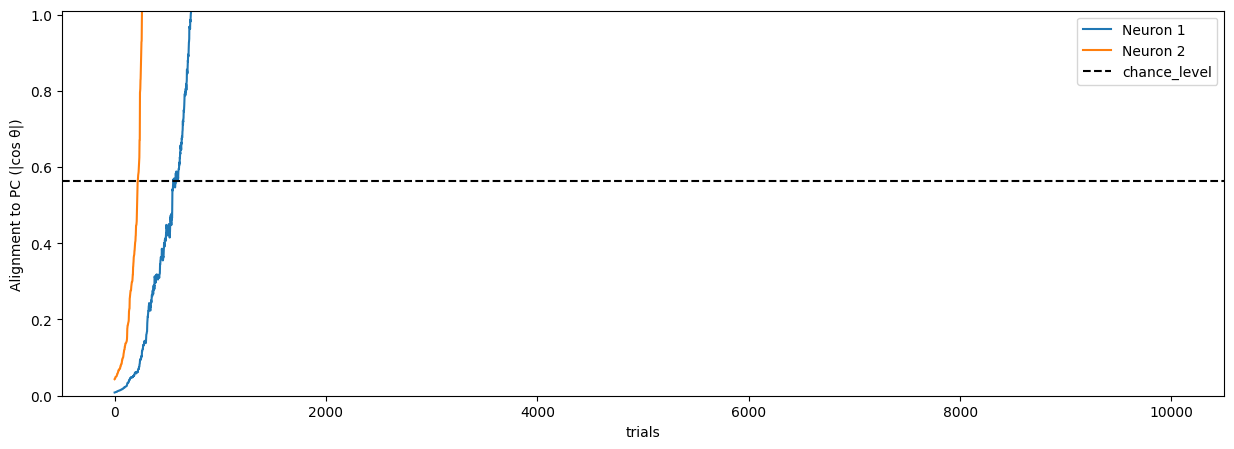

W after first phase: [[ 0.245425    0.42323395  0.11038151 -0.07021916 -0.17190769 -0.23549513
  -0.18635877 -0.08411452 -0.11612619  0.71837253]
 [-0.02481892  0.15051678  0.4780583  -0.09787799  0.34044739  0.39700494
  -0.27730692  0.50613307 -0.19192341 -0.06804572]]
X_after
W: [[ 0.245425    0.42323395  0.11038151 -0.07021916 -0.17190769 -0.23549513
  -0.18635877 -0.08411452 -0.11612619  0.71837253]
 [-0.02481892  0.15051678  0.4780583  -0.09787799  0.34044739  0.39700494
  -0.27730692  0.50613307 -0.19192341 -0.06804572]]
step    0 | order = [1 0] | best|corr|= [0.94  0.984]
step 1000 | order = [0 1] | best|corr|= [0.841 0.706]
step 2000 | order = [1 0] | best|corr|= [0.697 0.737]
step 3000 | order = [0 1] | best|corr|= [0.858 0.77 ]
step 4000 | order = [0 1] | best|corr|= [0.776 0.716]
step 5000 | order = [0 1] | best|corr|= [0.941 0.966]


In [ ]:
from hebbian.models import SangerNetwork
sanger_model = SangerNetwork(output_size=m, learning_rate=0.011, rng=None)

sanger_model_after = dict(learning_rate=0.01)

two_phase_training_testing(sanger_model, X_before, X_after, m, model_paras_after = sanger_model_after, runs = 10, graph = True)

In [ ]:
leen_model  = LeenCompletePCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, model_paras_after = None, runs = 10, graph = True)

In [ ]:
from hebbian.utils import pca_topk
from scipy.stats import pearsonr
from hebbian.utils import best_match_align_timeseries



def random_projection_chance_corr1(X, n_samples=1000, seed=None):
    """
    Calculate the expected absolute correlation between a random projection 
    of X and the PC projections of X.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    n_samples : int, default=1000
        Number of random vectors to sample for Monte Carlo estimation
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation between random projection and PC projections
    std_corr : float
        Standard deviation of correlations (for reference)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PCs
    _, _, PC_scores = pca_topk(X, d, center=True)
    print(f"shape of PC_scores: {PC_scores.shape}")
    
    # Sample random unit vectors
    rng = np.random.default_rng(seed)
    correlations = []
    
    for _ in range(n_samples):
        # Random unit vector in d-dimensional space
        w = rng.normal(size=d)
        w = w / (np.linalg.norm(w) + 1e-12)
        
        # Project X onto random direction
        y_random = Xc @ w
        
        # Compute correlation with each PC
        pc_corrs = []
        # print(f"shape of y_random: {y_random.shape}")
        
        # for j in range(min(d, PC_scores.shape[1])):
        # for j in range(2):
        # calculate the covariance between y_random and PC_scores[:, 0]
        cov = np.cov(y_random, PC_scores[:, 0])/np.cov(PC_scores[:, 0], PC_scores[:, 0])
        # pc_corrs.append(abs(r))
        pc_corrs.append(abs(cov[0, 1]))

        
        # Take max correlation (best match, like Hungarian algorithm does)
        correlations.append(max(pc_corrs))
    
    return np.mean(correlations), np.std(correlations)


def random_projection_chance_corr(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Calculate the expected absolute correlation between random projections 
    of X and the PC projections of X, using the same matching procedure
    as the actual analysis (best_match_align_timeseries).
    
    This generates m random unit vectors, projects X onto them, and uses
    Hungarian matching to find optimal alignment with PCs, just like the
    real analysis does.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    m : int, default=2
        Number of random projections (should match output_dim of your model)
    n_samples : int, default=1000
        Number of random vector sets to sample for Monte Carlo estimation
    metric : {"corr", "cosine"}, default="corr"
        Metric to use (should match what you use in best_match_align_timeseries)
    absolute : bool, default=True
        Whether to use absolute correlations (should match your usage)
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation after optimal matching
    std_corr : float
        Standard deviation of correlations (for reference)
    all_corrs : ndarray, shape (n_samples, m)
        All correlation values from each trial (for distribution analysis)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PC scores (top m PCs)
    _, _, PC_scores = pca_topk(X, d, center=True)
    PC_scores_m = PC_scores[:, :m]  # Use only top m PCs
    
    # Sample random projections
    rng = np.random.default_rng(seed)
    all_similarities = []
    
    for trial in range(n_samples):
        # Generate m random unit vectors in d-dimensional space
        W_random = rng.normal(size=(m, d))
        # Normalize each row to unit length
        W_random = W_random / (np.linalg.norm(W_random, axis=1, keepdims=True) + 1e-12)
        
        # Project X onto random directions: Y_random = Xc @ W_random.T
        # Shape: (n, d) @ (d, m) = (n, m)
        Y_random = Xc @ W_random.T
        
        # Use the same matching procedure as actual analysis
        perm, similarity, _, _ = best_match_align_timeseries(
            Y_random, PC_scores_m, 
            metric=metric, 
            absolute=absolute
        )
        
        # similarity is already the matched correlations
        all_similarities.append(similarity)
    
    all_similarities = np.array(all_similarities)  # Shape: (n_samples, m)
    
    # Compute statistics
    expected_corr = np.mean(all_similarities)
    std_corr = np.std(all_similarities)
    
    return expected_corr, std_corr, all_similarities


def random_projection_chance_corr_per_pc(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Same as random_projection_chance_corr but returns per-PC statistics.
    
    Returns
    -------
    expected_corr_per_pc : ndarray, shape (m,)
        Expected correlation for each PC (after sorting by PC order)
    std_corr_per_pc : ndarray, shape (m,)
        Standard deviation for each PC
    """
    expected_corr, std_corr, all_similarities = random_projection_chance_corr(
        X, m, n_samples, metric, absolute, seed
    )
    
    # Sort similarities by PC order (they're already matched, but we want PC1, PC2, ...)
    # The similarities are already optimally matched, so we sort them
    all_similarities_sorted = np.sort(all_similarities, axis=1)  # Sort each row
    
    expected_corr_per_pc = np.mean(all_similarities_sorted, axis=0)
    std_corr_per_pc = np.std(all_similarities_sorted, axis=0)
    
    return expected_corr_per_pc, std_corr_per_pc, all_similarities_sorted



def analytical_chance_corr(input_dim):
    """
    Analytical approximation for expected correlation between random projection
    and PC projection, assuming isotropic data (all eigenvalues equal).
    
    This is a simplified case. For non-isotropic data, use random_projection_chance_corr.
    
    Parameters
    ----------
    input_dim : int
        Input dimensionality
        
    Returns
    -------
    float 
        Expected absolute correlation (approximate)
    """
    # For isotropic case, this reduces to the random vector chance level
    # For non-isotropic, it's more complex and depends on eigenvalue distribution
    return np.sqrt(2 / (np.pi * input_dim))

In [ ]:
print(f"Analytical chance correlation: {analytical_chance_corr(N):.3f}")

In [ ]:
from hebbian.utils import generate_covariance_matrix
for i in range(2, 10, 1):
    N = i
    m = 2
    phi_deg = 45.0
    n_samples = 10001
    # get /sigma
    Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
    Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

    X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)
    print(f" input dimension = {N}")
    print(f"shape of X_before: {X_before.shape}")
    # In Y_aligned_training_testing_online or similar:
    expected_corr, std_corr = random_projection_chance_corr1(X_before, n_samples=1000)
    print(f"Expected chance correlation: {expected_corr:.3f} ± {std_corr:.3f}")

In [ ]:
# In your notebook or analysis:

# Or get per-PC statistics
expected_per_pc, std_per_pc, _ = random_projection_chance_corr_per_pc(
    X_before, m=2, n_samples=1000
)
print(f"Expected chance correlation per PC: PC1={expected_per_pc[0]:.3f}, PC2={expected_per_pc[1]:.3f}")